# ROC curve

our classification's algos find probability if the probab is > threshold we set it to 1 (in binary ) and if probab<threshold we assign it 0 .

Generally this threshold is 0.5 but it is not alaways perfect .

ROC curve helps us in detrming perfect value of threshold.

TPR = TP/(TP+FN)
FPR = FP/(FP+TN)

here TPR-true positive rate also knows as benefit
     FPR-False positive rate also known as cost
     TP-True Positive
     FP-False Positive
     TN-True Negative
     FN-False Negative

Our end goal is to maximise the benefit and minimise the cost
=> we want to maximise our TPR and decrease FPR => on roc curve x-close to 0 and y-close to 1
=>best threshold value is the one which is closest to 0,1 in roc curve

Threshold effect on ROC curve

    Threshold very high (say 0.95) => True Positive decrease => TPR decreases
                                and False Positive also decreases => FPR decreases => roc curve near to 0,0
    
    Threshold ver low (say 0.05) =>True Positive increases => TPR increases
                                and False Positive also increases => FPR increases=> roc curve near to 1,1

In [29]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

In [4]:
X,y=make_classification(n_samples=2000,n_features=3,n_informative=3,n_redundant=0,random_state=42)

In [20]:
model=LogisticRegression()
model.fit(X[200:,:],y[200:])
y_prob=model.predict_proba(X[:200,:])[:,1] #probability that any point will belong to class 1

In [24]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y[:200].reshape(200,1),y_prob)

In [48]:
a=np.linspace(0,1,100)

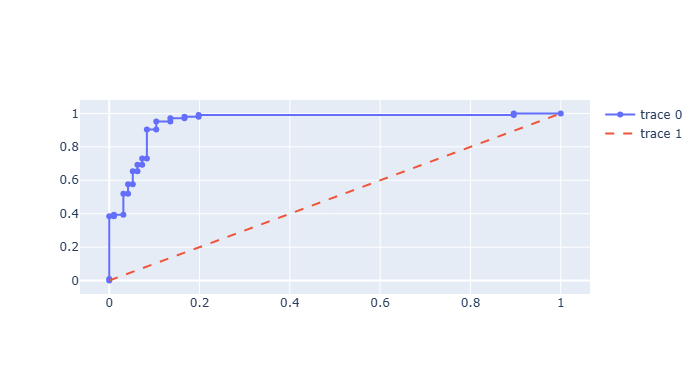

In [53]:
trace1=go.Scatter(x=fpr,y=tpr,mode='lines+markers',hovertext=[f"threshold= {i}" for i in thresholds])
trace2=go.Scatter(x=a,y=a,mode='lines',line=dict(dash='dash'))
go.Figure(data=[trace1,trace2],layout=None)

In [46]:
# optimal threshold 
dist=np.sqrt(fpr**2 + (1 - tpr)**2)
thresholds[np.argmin(dist)]

0.5687867902945695

# ROC-AUC curve

here auc stands for area under curve

if auc=1 it means that our model can classify perfectly<br>
if auc=0 it means that our model can classify perfectly opposite 

auc can be used to compare model

higher auc means model perform better across all threshold values